# 단변수 데이터 분석

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import platform

if platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='DejaVu Sans')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print('NumPy 버전:', np.__version__)
print('환경 설정 완료')

NumPy 버전: 2.3.5
환경 설정 완료


In [32]:
import pandas as pd

### 1. 범주형 데이터

In [33]:
season = pd.Series(['봄','여름','가을','겨울', '봄', '봄','여름','가을'])

In [3]:
# 도수분포 확인
season.value_counts()

봄     3
여름    2
가을    2
겨울    1
Name: count, dtype: int64

In [5]:
# 비율 계산
(season.value_counts() / season.size).round(2) 

봄     0.38
여름    0.25
가을    0.25
겨울    0.12
Name: count, dtype: float64

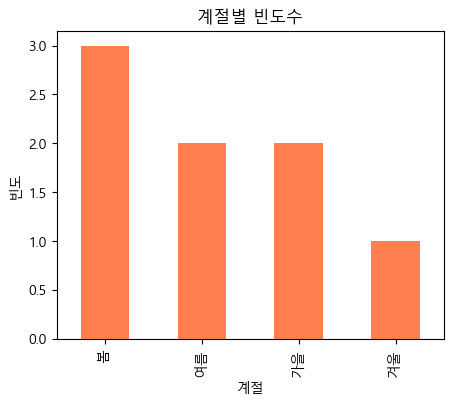

In [11]:
# 시각화 - 막대그래프
fd = season.value_counts()
fd.plot(
    kind='bar',
    figsize=(5,4),
    color=('coral')
)
plt.xlabel('계절')
plt.ylabel('빈도')
plt.title('계절별 빈도수')
plt.show()

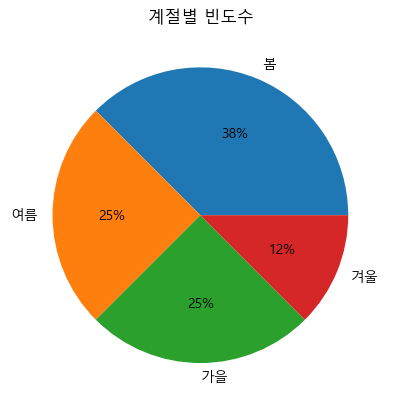

In [17]:
# 시각화 - 원그래프
fd = season.value_counts()
fd.plot(
    kind='pie',
    autopct='%1.0f%%',
    color=('coral')
)
plt.ylabel('')
plt.title('계절별 빈도수')
plt.show()

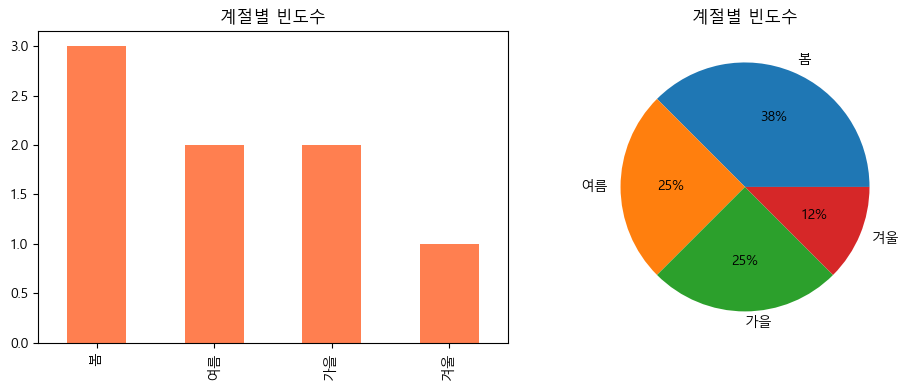

In [31]:
# 시각화 - 막대 그래프, 원 그래프
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 막대 그래프
fd.plot.bar( 
    ax = axes[0], 
    color=('coral'),
    title= '계절별 빈도수'
)

# 원 그래프
fd.plot.pie( 
    ax = axes[1], 
    autopct = '%1.0f%%',
    ylabel = '',
    title= '계절별 빈도수'
)
plt.tight_layout()
plt.show()

### 2. 수치형 데이터

In [39]:
from scipy import stats

# 정상적인 몸무게 데이터 
weight1 = pd.Series([60, 62, 65, 66, 64, 63])

# 이상치 데이터 추가
weight2 = pd.Series([60, 62, 65, 66, 64, 63, 150])

In [44]:
# 평균 구하기
print(f"mean1 : {weight1.mean():.1f}")
print(f"mean2 : {weight2.mean():.1f}")

# 중앙값 구하기
print(f"median1 : {weight1.median():.1f}")
print(f"median2 : {weight2.median():.1f}")

# 절사평균 구하기
print(f"절사평균(20%): {stats.trim_mean(weight2, 0.2):.1f} ")

mean1 : 63.3
mean2 : 75.7
median1 : 63.5
median2 : 64.0
절사평균(20%): 64.0 


In [45]:
# 사분위수 구하기
mydata = pd.Series([60, 62, 64, 65, 68, 69, 120])

Q1 = mydata.quantile(0.25)
Q2 = mydata.quantile(0.50)
Q3 = mydata.quantile(0.75)
IQR = Q3 - Q1

print(f'Q1: {Q1}')
print(f'Q2: {Q2}')
print(f'Q3: {Q3}')
print(f'IQR: {IQR}')

Q1: 63.0
Q2: 65.0
Q3: 68.5
IQR: 5.5


In [50]:
# 분산과 표준편차
# 표준편차가 작을수록 데이터가 밀집해 있음
mydata = pd.Series([60, 62, 64, 65, 68, 69, 72])
var_result = float(mydata.var())
var_std = float(mydata.std())

print('평균 (mean):', mydata.mean().round())
print('분산 (var):', var_result)
print('표준편차 (std):', var_std) # 표준편차 15이상이면 평균 주위에 넓게 퍼져있음
mydata.describe()

평균 (mean): 66.0
분산 (var): 17.57142857142857
표준편차 (std): 4.191828786034631


count     7.000000
mean     65.714286
std       4.191829
min      60.000000
25%      63.000000
50%      65.000000
75%      68.500000
max      72.000000
dtype: float64

In [ ]:
# 수치형 데이터의 시각화 - 히스토그램
mydata.plot(
    kind='hist',
    bins=10,
    color='gray'
)
plt.show()

- 실습 데이터 준비 : iris.csv

In [55]:
# iris 데이터 로드
iris_df = pd.read_csv('data/iris.csv')
iris_df.dtypes
iris_df.shape
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


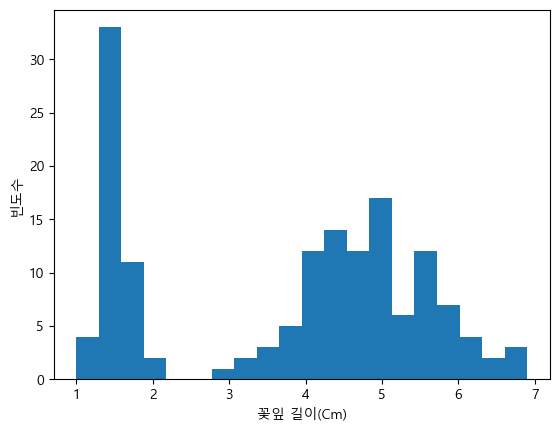

In [62]:
# 꽃잎의 길이(PetalLengthCm)를 통한 분포 확인
iris_df['PetalLengthCm'].plot(
    kind='hist',
    bins = 20
)
plt.xlabel('꽃잎 길이(Cm)')
plt.ylabel('빈도수')
plt.show()

In [68]:
iris_df['Species'].unique()
iris_df.groupby('Species')['PetalLengthCm'].mean()

Species
Iris-setosa        1.464
Iris-versicolor    4.260
Iris-virginica     5.552
Name: PetalLengthCm, dtype: float64

- 타이타닉 데이터 셋 로드

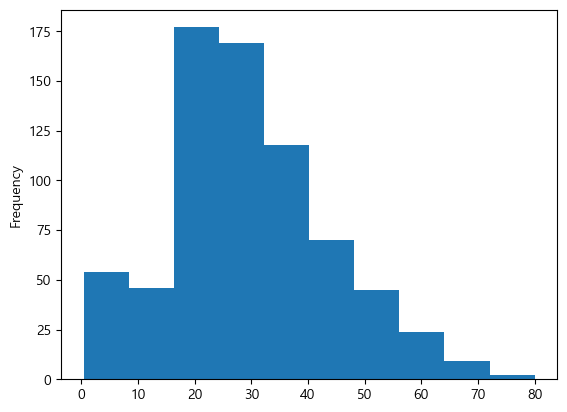

In [70]:
# 승객의 나이가 어느 중심에 분포되어 있는가?
titanic_df = pd.read_csv('data/titanic/train.csv')
titanic_df.head()

titanic_df['Age'].plot(
    kind='hist',
    bins= 10
)
plt.show()

In [ ]:
titanic_df.head()
em_dict = {
    'S':1,
    'C':2,
    'E':3
}
titanic_df['Em'] = titanic_df['Embarked'].map(em_dict)
titanic_df

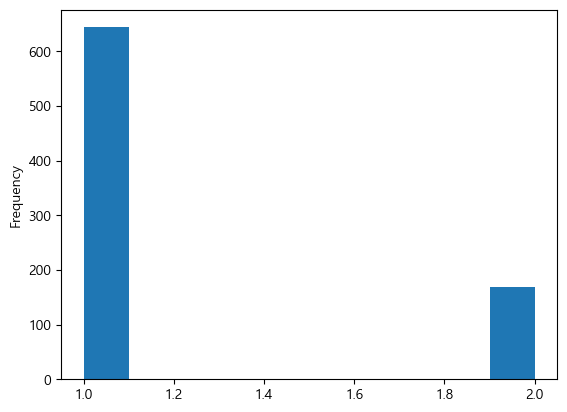

In [75]:
# 어느 항구에서 승선을 많이 했는지?
titanic_df['Em'].plot(
    kind='hist',
    bins= 10
)
plt.show()

In [76]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  Em           812 non-null    float64
dtypes: float64(3), int64(5), object(5)
memory usage: 90.6+ KB


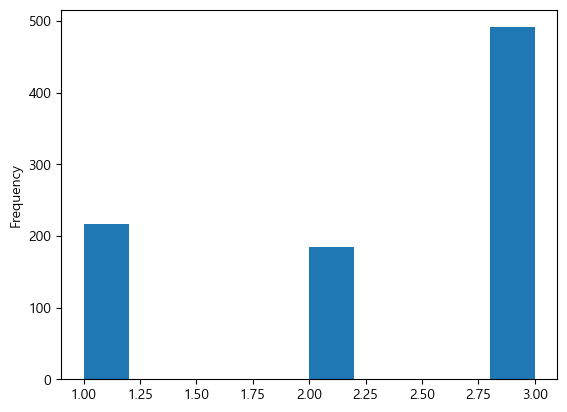

In [77]:
titanic_df['Pclass'].plot(
    kind='hist',
    bins=10
)
plt.show()

In [79]:
titanic_df.head()
titanic_df.loc[0, 'Age'] = 1000

In [80]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Em
0,1,0,3,"Braund, Mr. Owen Harris",male,1000.0,1,0,A/5 21171,7.2500,NaN,S,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1.0


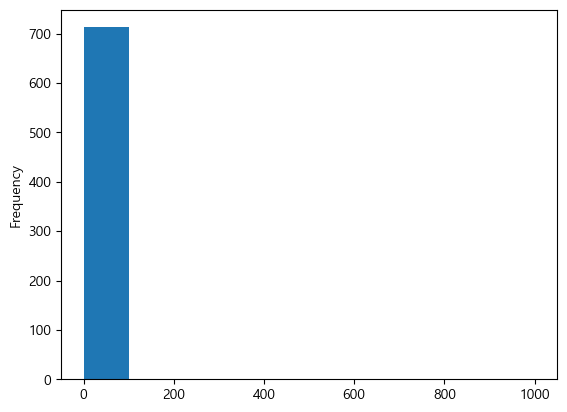

In [81]:
titanic_df['Age'].plot(
    kind='hist',
    bins= 10
)
plt.show()

In [84]:
print(titanic_df['Age'].mean())
print(titanic_df['Age'].median())
print(titanic_df['Age'].min())
print(titanic_df['Age'].max())

31.068865546218486
28.0
0.42
1000.0
